In [ ]:
import os
import time
import pip
import requests
from bs4 import BeautifulSoup as bs
from selenium import webdriver 
from selenium.webdriver.common.by import By # This needs to be used 
%pip install pymongo python-dotenv



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# from pymongo import MongoClient
# from dotenv import load_dotenv
# import os

# load_dotenv()

# mongo_url = os.getenv("MONGO_DB_URL")

# client = MongoClient(mongo_url)

# db = client["myntra_reviews"]
# collection = db["products"]

# print("Connected Successfully")

Connected Successfully


In [4]:
from selenium import webdriver


product="white shoes"
# Define the path to the Chrome WebDriver executable

# Initialize the Chrome WebDriver
driver = webdriver.Chrome()

driver.get("https://www.myntra.com/shoes?rawQuery="+product)

# Wait for the page to load (you may need to adjust the waiting time)
# You can use WebDriverWait for this purpose.
# Example: WebDriverWait(driver, 10).until(lambda x: x.find_element_by_id("element_id").is_displayed())

# Once the page is loaded, you can extract the page's text
myntra_text = driver.page_source


myntra_html = bs(myntra_text, "html.parser")  # from the markup format we are converting to html format

<html lang="en"><head><title>Shop the Latest Shoes for Men, Women &amp; Kids Online | Best Prices &amp; Up to 50% Off | Myntra</title><meta content="#fffff" name="theme-color"/><link href="https://constant.myntassets.com" rel="dns-prefetch preconnect"/><link href="https://assets.myntassets.com" rel="dns-prefetch preconnect"/><link href="https//www.googletagmanager.com" rel="dns-prefetch preconnect"/><link href="https//www.google-analytics.com" rel="dns-prefetch preconnect"/><link href="https//connect.facebook.net" rel="dns-prefetch preconnect"/><link href="https://www.facebook.com" rel="dns-prefetch preconnect"/><link href="https://touch.myntra.com" rel="dns-prefetch preconnect"/><link href="/manifest.json" rel="manifest"/><link href="https://www.myntra.com/opensearch.xml" rel="search" title="Myntra Fashion Search" type="application/opensearchdescription+xml"/><link href="https://constant.myntassets.com/pwa/assets/img/Icon-App-60x60@3x_2021.png" rel="apple-touch-icon"/>
<link as="scrip
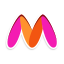

In [5]:
myntra_html

'<html lang="en"><head><title>Shop the Latest Shoes for Men, Women &amp; Kids Online | Best Prices &amp; Up to 50% Off | Myntra</title><meta name="theme-color" content="#fffff"><link rel="dns-prefetch preconnect" href="https://constant.myntassets.com"><link rel="dns-prefetch preconnect" href="https://assets.myntassets.com"><link rel="dns-prefetch preconnect" href="https//www.googletagmanager.com"><link rel="dns-prefetch preconnect" href="https//www.google-analytics.com"><link rel="dns-prefetch preconnect" href="https//connect.facebook.net"><link rel="dns-prefetch preconnect" href="https://www.facebook.com"><link rel="dns-prefetch preconnect" href="https://touch.myntra.com"><link rel="manifest" href="/manifest.json"><link rel="search" type="application/opensearchdescription+xml" href="https://www.myntra.com/opensearch.xml" title="Myntra Fashion Search"><link rel="apple-touch-icon" href="https://constant.myntassets.com/pwa/assets/img/Icon-App-60x60@3x_2021.png">\n      <link rel="preload
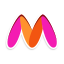

In [6]:
myntra_text

In [ ]:
pclass = myntra_html.findAll("ul", {"class": "results-base"})  # similar to pattern matching in regex
# Extract the first element from the list
if pclass:
    print(pclass[0])


<ul class="results-base"><li class="product-base" id="34970593"><div class="product-thumbShim"></div><div class="product-ratingsContainer"><span>4.4</span><span class="myntraweb-sprite product-starIcon index-productRatingsExcellentIcon sprites-productRatingsExcellentIcon"></span><div class="product-ratingsCount"><div class="product-separator">|</div><!-- react-text: 384 -->1.6k<!-- /react-text --></div></div><div class="product-waterMark"> AD </div><a data-refreshpage="true" href="sports-shoes/puma/puma-galaxis-pro-womens-performance-boost-running-shoes/34970593/buy" style="display: block;" target="_blank"><div class="product-imageSliderContainer"><div class="product-sliderContainer" style="display: block;"><div style="background: rgb(229, 241, 255);"><div style="height: 280px; width: 100%;"><picture class="img-responsive" draggable="false" style="width: 100%; height: 100%; display: block;"><source srcset="
    https://assets.myntassets.com/f_webp,dpr_1.0,q_60,w_210,c_limit,fl_progress

In [ ]:
t = None  # Initialize before loop
for i in pclass:
    href = i.find_all('a', href=True)
    if href:
        t = href[0]['href']
        break
   
productLink = "https://www.myntra.com/" + (t if t else "")
productLink


'https://www.myntra.com/sports-shoes/puma/puma-galaxis-pro-womens-performance-boost-running-shoes/34970593/buy'

In [9]:
driver.get(productLink)
prodRes= driver.page_source

'<html lang="en"><head><title>Buy Puma Galaxis Pro Women\'s Performance Boost Running Shoes  - Sports Shoes for Women 34970593 | Myntra</title><meta name="theme-color" content="#fffff"><link rel="dns-prefetch preconnect" href="https://constant.myntassets.com"><link rel="dns-prefetch preconnect" href="https://assets.myntassets.com"><link rel="dns-prefetch preconnect" href="https//www.googletagmanager.com"><link rel="dns-prefetch preconnect" href="https//www.google-analytics.com"><link rel="dns-prefetch preconnect" href="https//connect.facebook.net"><link rel="dns-prefetch preconnect" href="https://www.facebook.com"><link rel="dns-prefetch preconnect" href="https://touch.myntra.com"><link rel="manifest" href="/manifest.json"><link rel="search" type="application/opensearchdescription+xml" href="https://www.myntra.com/opensearch.xml" title="Myntra Fashion Search"><link rel="apple-touch-icon" href="https://constant.myntassets.com/pwa/assets/img/Icon-App-60x60@3x_2021.png">\n      <link rel=
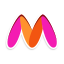

In [10]:
prodRes

<html lang="en"><head><title>Buy Puma Galaxis Pro Women's Performance Boost Running Shoes  - Sports Shoes for Women 34970593 | Myntra</title><meta content="#fffff" name="theme-color"/><link href="https://constant.myntassets.com" rel="dns-prefetch preconnect"/><link href="https://assets.myntassets.com" rel="dns-prefetch preconnect"/><link href="https//www.googletagmanager.com" rel="dns-prefetch preconnect"/><link href="https//www.google-analytics.com" rel="dns-prefetch preconnect"/><link href="https//connect.facebook.net" rel="dns-prefetch preconnect"/><link href="https://www.facebook.com" rel="dns-prefetch preconnect"/><link href="https://touch.myntra.com" rel="dns-prefetch preconnect"/><link href="/manifest.json" rel="manifest"/><link href="https://www.myntra.com/opensearch.xml" rel="search" title="Myntra Fashion Search" type="application/opensearchdescription+xml"/><link href="https://constant.myntassets.com/pwa/assets/img/Icon-App-60x60@3x_2021.png" rel="apple-touch-icon"/>
<link as
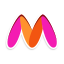

In [11]:
prodRes_html = bs(prodRes, "html.parser")
prodRes_html

In [12]:
title_h=prodRes_html.findAll("title")  # used for filtering by Title tag
# Extract the first element from the list
title=title_h[0].text
title

"Buy Puma Galaxis Pro Women's Performance Boost Running Shoes  - Sports Shoes for Women 34970593 | Myntra"

In [ ]:
overallRating = prodRes_html.findAll("div", {"class": "index-overallRating"})
print(overallRating)
rating_value = ""  # Initialize before loop
for i in overallRating:
    rating_value = i.find('div').text
    
print(rating_value)


[<div class="index-overallRating"><div>4.4</div><span class="myntraweb-sprite index-starIcon index-productRatingsExcellentIcon sprites-productRatingsExcellentIcon"></span><div class="index-separator">|</div><div class="index-ratingsCount"><!-- react-text: 82 -->1.6k<!-- /react-text --><!-- react-text: 83 --> Ratings<!-- /react-text --></div></div>]
4.4


In [ ]:
price = prodRes_html.findAll("span", {"class": "pdp-price"})
p = ""  # Initialize before loop
for i in price:
    p = i.text
print(p)


₹2799


In [15]:
# Search for review-related links
print("Links containing 'review':\n")
for link in prodRes_html.find_all("a"):
    href = link.get('href', '')
    classes = link.get('class', [])
    text = link.text.strip()
    
    if 'review' in href.lower() or 'review' in text.lower() or any('review' in str(c).lower() for c in classes):
        print(f"Classes: {classes}")
        print(f"Href: {href}")
        print(f"Text: {text}\n")


Links containing 'review':

Classes: ['detailed-reviews-allReviews']
Href: /reviews/34970593
Text: View all 238 reviews



In [16]:
Reviews=prodRes_html.find("a",{"class":"detailed-reviews-allReviews"})
t2=Reviews['href']
Review_link="https://www.myntra.com"+t2
Review_link

'https://www.myntra.com/reviews/34970593'

In [17]:
driver.get(Review_link)
review_page = driver.page_source
driver.quit()

<html lang="en"><head><title>Review - Puma Galaxis Pro Women's Performance Boost Running Shoes</title><meta content="#fffff" name="theme-color"/><link href="https://constant.myntassets.com" rel="dns-prefetch preconnect"/><link href="https://assets.myntassets.com" rel="dns-prefetch preconnect"/><link href="https//www.googletagmanager.com" rel="dns-prefetch preconnect"/><link href="https//www.google-analytics.com" rel="dns-prefetch preconnect"/><link href="https//connect.facebook.net" rel="dns-prefetch preconnect"/><link href="https://www.facebook.com" rel="dns-prefetch preconnect"/><link href="https://touch.myntra.com" rel="dns-prefetch preconnect"/><link href="/manifest.json" rel="manifest"/><link href="https://www.myntra.com/opensearch.xml" rel="search" title="Myntra Fashion Search" type="application/opensearchdescription+xml"/><link href="https://constant.myntassets.com/pwa/assets/img/Icon-App-60x60@3x_2021.png" rel="apple-touch-icon"/>
<link as="script" href="https://constant.myntas
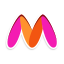

In [18]:
review_html = bs(review_page,"html.parser")
review_html

In [19]:
review=review_html.findAll("div",{"class":"detailed-reviews-userReviewsContainer"})
review

[<div class="detailed-reviews-userReviewsContainer" id="detailedReviewsContainer"><div class="user-review-userReviewWrapper"><div class="user-review-main user-review-showRating"><div class="user-review-starWrapper"><span class="user-review-starRating user-review-fiveStars"><!-- react-text: 132 -->5<!-- /react-text --><span class="user-review-starIcon"><svg height="10" viewbox="0 0 12 12" width="10" xmlns="http://www.w3.org/2000/svg"><path d="M6 9.644l2.867 1.821c.464.296.743.093.623-.45L8.724 7.56l2.581-2.657c.384-.395.25-.716-.306-.716H7.686L6.374.93c-.206-.513-.542-.512-.748 0L4.314 4.187H1.001c-.553 0-.687.324-.306.716L3.276 7.56l-.766 3.455c-.12.544.165.742.623.45L6 9.645z" fill="#FFF" fill-rule="evenodd"></path></svg></span></span></div><div class="user-review-reviewTextWrapper">I recently got a pair of Puma shoes and I honestly didn’t expect to fall in love with them this much 💫
 
 From the moment I wore them, they felt incredibly comfortable—like they were made just for my feet.

In [20]:
for i in review:
    user_rating=i.findAll("div",{"class":"user-review-main user-review-showRating"})
    user_comment=i.findAll("div",{"class":"user-review-reviewTextWrapper"})
    user_name=i.findAll("div",{"class":"user-review-left"})
    user_rating

In [21]:
len(user_rating),len(user_comment),len(user_name)

(12, 12, 12)

In [22]:
user_comment

[<div class="user-review-reviewTextWrapper">I recently got a pair of Puma shoes and I honestly didn’t expect to fall in love with them this much 💫
 
 From the moment I wore them, they felt incredibly comfortable—like they were made just for my feet. The cushioning is perfect, not too soft and not too hard, making them ideal for long days, whether I’m at school, walking around, or just out and about.
 
 And can we talk about the style? 😍 They look so sleek and trendy that they instantly upgrade any outfit. I’ve gotten so many compliments already!
 
  totally worth it—Puma is definitely the way to go. 100% recommended! 🖤✨</div>,
 <div class="user-review-reviewTextWrapper">Product looks great, slightly light pinkish shade with yellow stripes. Profoam technology returns energy while running. Good quality shoe for running 5-10kms. Insole is not that soft. 
 It has good grip and is ideal for road running</div>,
 <div class="user-review-reviewTextWrapper">I was expecting it to be completely w

In [23]:
user_rating

[<div class="user-review-main user-review-showRating"><div class="user-review-starWrapper"><span class="user-review-starRating user-review-fiveStars"><!-- react-text: 132 -->5<!-- /react-text --><span class="user-review-starIcon"><svg height="10" viewbox="0 0 12 12" width="10" xmlns="http://www.w3.org/2000/svg"><path d="M6 9.644l2.867 1.821c.464.296.743.093.623-.45L8.724 7.56l2.581-2.657c.384-.395.25-.716-.306-.716H7.686L6.374.93c-.206-.513-.542-.512-.748 0L4.314 4.187H1.001c-.553 0-.687.324-.306.716L3.276 7.56l-.766 3.455c-.12.544.165.742.623.45L6 9.645z" fill="#FFF" fill-rule="evenodd"></path></svg></span></span></div><div class="user-review-reviewTextWrapper">I recently got a pair of Puma shoes and I honestly didn’t expect to fall in love with them this much 💫
 
 From the moment I wore them, they felt incredibly comfortable—like they were made just for my feet. The cushioning is perfect, not too soft and not too hard, making them ideal for long days, whether I’m at school, walking a

In [24]:
for i in range(len(user_rating)):
    rating = user_rating[i].find('span', class_='user-review-starRating').get_text().strip()
    comment=user_comment[i].text
    name = user_name[i].find('span').text
    date = user_name[i].find_all('span')[1].text    
    print(f"Date: {date},Rating: {rating},Name:{name},Comment:{comment}")

Date: 12 Apr 2026,Rating: 5,Name:Shobha Devi,Comment:I recently got a pair of Puma shoes and I honestly didn’t expect to fall in love with them this much 💫

From the moment I wore them, they felt incredibly comfortable—like they were made just for my feet. The cushioning is perfect, not too soft and not too hard, making them ideal for long days, whether I’m at school, walking around, or just out and about.

And can we talk about the style? 😍 They look so sleek and trendy that they instantly upgrade any outfit. I’ve gotten so many compliments already!

 totally worth it—Puma is definitely the way to go. 100% recommended! 🖤✨
Date: 26 May 2026,Rating: 5,Name:Mri Dameme,Comment:Product looks great, slightly light pinkish shade with yellow stripes. Profoam technology returns energy while running. Good quality shoe for running 5-10kms. Insole is not that soft. 
It has good grip and is ideal for road running
Date: 10 Nov 2025,Rating: 4,Name:Prerana Wakode,Comment:I was expecting it to be comp

In [25]:
for i in user_comment:
    com=i.text
    print(com)

I recently got a pair of Puma shoes and I honestly didn’t expect to fall in love with them this much 💫

From the moment I wore them, they felt incredibly comfortable—like they were made just for my feet. The cushioning is perfect, not too soft and not too hard, making them ideal for long days, whether I’m at school, walking around, or just out and about.

And can we talk about the style? 😍 They look so sleek and trendy that they instantly upgrade any outfit. I’ve gotten so many compliments already!

 totally worth it—Puma is definitely the way to go. 100% recommended! 🖤✨
Product looks great, slightly light pinkish shade with yellow stripes. Profoam technology returns energy while running. Good quality shoe for running 5-10kms. Insole is not that soft. 
It has good grip and is ideal for road running
I was expecting it to be completely white but to my surprise it has very light pinkish tint. It is comfortable for the gym workout. Not as light weight as i was expecting it to be. But the s

In [26]:
for item in user_name[:5]:
    name = item.find('span').text
    date = item.find_all('span')[1].text
    print(f"Name: {name}, Date: {date}")

Name: Shobha Devi, Date: 12 Apr 2026
Name: Mri Dameme, Date: 26 May 2026
Name: Prerana Wakode, Date: 10 Nov 2025
Name: Yukta Pandey, Date: 6 Dec 2025
Name: Myntra Customer, Date: 8 Apr 2026


In [27]:
from urllib.parse import quote


search_query = "denim jeans"
encoded_query = quote(search_query)
encoded_query

'denim%20jeans'

In [28]:
import requests
from bs4 import BeautifulSoup

url = 'https://en.wikipedia.org/wiki/Elon_Musk'

# Sending a GET request to the URL
response = requests.get(url)

# Parsing the HTML content using BeautifulSoup
soup = BeautifulSoup(response.text, 'html.parser')

# Finding all anchor tags (a) that contain href attribute
href_tags = soup.find_all('a', href=True)

# Extracting href attribute from anchor tags
href_links = [tag['href'] for tag in href_tags]

print(href_links)


[]


C:\Users\victus\AppData\Local\Temp\ipykernel_7016\2536961087.py:10: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(response.text, 'html.parser')


In [ ]:
# Install TextBlob for sentiment analysis
%pip install textblob



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
from textblob import TextBlob
import pandas as pd

# Extract reviews from the scraped user_comment
reviews_list = []

# Get all review comments
if user_comment:
    for comment in user_comment:
        review_text = comment.text.strip()
        if review_text:
            reviews_list.append(review_text)

print(f"Total reviews collected: {len(reviews_list)}\n")
print("Sample reviews:")
for i, review in enumerate(reviews_list[:5]):
    print(f"{i+1}. {review}\n")


Total reviews collected: 12

Sample reviews:
1. I recently got a pair of Puma shoes and I honestly didn’t expect to fall in love with them this much 💫

From the moment I wore them, they felt incredibly comfortable—like they were made just for my feet. The cushioning is perfect, not too soft and not too hard, making them ideal for long days, whether I’m at school, walking around, or just out and about.

And can we talk about the style? 😍 They look so sleek and trendy that they instantly upgrade any outfit. I’ve gotten so many compliments already!

 totally worth it—Puma is definitely the way to go. 100% recommended! 🖤✨

2. Product looks great, slightly light pinkish shade with yellow stripes. Profoam technology returns energy while running. Good quality shoe for running 5-10kms. Insole is not that soft. 
It has good grip and is ideal for road running

3. I was expecting it to be completely white but to my surprise it has very light pinkish tint. It is comfortable for the gym workout. No

In [ ]:
# Function to classify sentiment
def classify_sentiment(polarity):
    """
    Classify sentiment based on polarity score
    Polarity ranges from -1 (negative) to 1 (positive)
    """
    if polarity > 0.1:
        return 'Positive'
    elif polarity < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

# Perform sentiment analysis on all reviews
sentiment_results = []

for review in reviews_list:
    try:
        blob = TextBlob(review)
        sentiment_obj = blob.sentiment
        polarity = float(sentiment_obj.polarity) if sentiment_obj else 0.0
        sentiment = classify_sentiment(polarity)
        
        sentiment_results.append({
            'Review': review,
            'Polarity': round(polarity, 3),
            'Sentiment': sentiment
        })
    except Exception as e:
        print(f"Error processing review: {e}")

# Create DataFrame
reviews_df = pd.DataFrame(sentiment_results)
print(f"Sentiment Analysis Complete!\n")
print(reviews_df.head(10))


Sentiment Analysis Complete!

                                              Review  Polarity Sentiment
0  I recently got a pair of Puma shoes and I hone...     0.359  Positive
1  Product looks great, slightly light pinkish sh...     0.514  Positive
2  I was expecting it to be completely white but ...     0.352  Positive
3  Bought this for gym purpose best sports shoes ...     0.700  Positive
4  The shoes fit perfectly. They are soft and com...     0.480  Positive
5  Awsm n perfectly fit tysm puma n myntra 🥰 Awsm...     0.667  Positive
6  Light weight so comfortable for running and  w...     0.400  Positive
7  I have purchased these shoes for my sibling bu...     0.262  Positive
8  Magic of Puma always surprises me. It has so m...     0.200  Positive
9                                     Good quality 💯     0.700  Positive


In [32]:
# Separate reviews by sentiment
positive_reviews = reviews_df[reviews_df['Sentiment'] == 'Positive']
negative_reviews = reviews_df[reviews_df['Sentiment'] == 'Negative']
neutral_reviews = reviews_df[reviews_df['Sentiment'] == 'Neutral']

print("=" * 80)
print("POSITIVE REVIEWS")
print("=" * 80)
print(f"Count: {len(positive_reviews)}\n")
for idx, row in positive_reviews.head(5).iterrows():
    print(f"Review: {row['Review']}")
    print(f"Polarity Score: {row['Polarity']}\n")

print("\n" + "=" * 80)
print("NEGATIVE REVIEWS")
print("=" * 80)
print(f"Count: {len(negative_reviews)}\n")
for idx, row in negative_reviews.head(5).iterrows():
    print(f"Review: {row['Review']}")
    print(f"Polarity Score: {row['Polarity']}\n")

print("\n" + "=" * 80)
print("NEUTRAL REVIEWS")
print("=" * 80)
print(f"Count: {len(neutral_reviews)}\n")
for idx, row in neutral_reviews.head(5).iterrows():
    print(f"Review: {row['Review']}")
    print(f"Polarity Score: {row['Polarity']}\n")


POSITIVE REVIEWS
Count: 12

Review: I recently got a pair of Puma shoes and I honestly didn’t expect to fall in love with them this much 💫

From the moment I wore them, they felt incredibly comfortable—like they were made just for my feet. The cushioning is perfect, not too soft and not too hard, making them ideal for long days, whether I’m at school, walking around, or just out and about.

And can we talk about the style? 😍 They look so sleek and trendy that they instantly upgrade any outfit. I’ve gotten so many compliments already!

 totally worth it—Puma is definitely the way to go. 100% recommended! 🖤✨
Polarity Score: 0.359

Review: Product looks great, slightly light pinkish shade with yellow stripes. Profoam technology returns energy while running. Good quality shoe for running 5-10kms. Insole is not that soft. 
It has good grip and is ideal for road running
Polarity Score: 0.514

Review: I was expecting it to be completely white but to my surprise it has very light pinkish tint.

Sentiment Distribution:
Sentiment
Positive    12
Name: count, dtype: int64

Total Reviews: 12


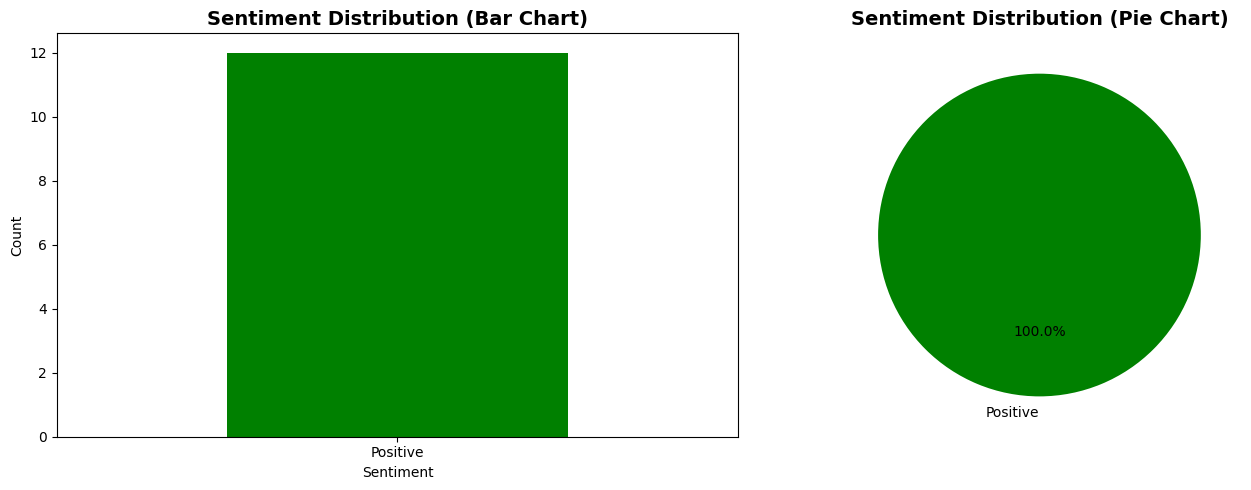


✓ Sentiment Analysis Complete!


In [33]:
# Sentiment Distribution Summary
import matplotlib.pyplot as plt

sentiment_counts = reviews_df['Sentiment'].value_counts()

print("Sentiment Distribution:")
print(sentiment_counts)
print(f"\nTotal Reviews: {len(reviews_df)}")

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
sentiment_counts.plot(kind='bar', ax=axes[0], color=['green', 'red', 'blue'])
axes[0].set_title('Sentiment Distribution (Bar Chart)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Pie chart
axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%',
            colors=['green', 'red', 'blue'], startangle=90)
axes[1].set_title('Sentiment Distribution (Pie Chart)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Sentiment Analysis Complete!")
